## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import wget
import os, io, math, random, time, json
import numpy as np
import torch, torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
if not os.path.exists('sonnets.txt'):
    wget.download('https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt')

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text_shakespeare = text[TEXT_START : TEXT_END]
assert len(text_shakespeare) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
import string

# Join all the strings into one and lowercase it
# Put result into variable text.
text_shakespeare = "".join(text_shakespeare).lower()
# Your great code here

assert len(text_shakespeare) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text_shakespeare) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')
text_shakespeare

OK!


"  from fairest creatures we desire increase,\n  that thereby beauty's rose might never die,\n  but as the riper should by time decease,\n  his tender heir might bear his memory:\n  but thou, contracted to thine own bright eyes,\n  feed'st thy light's flame with self-substantial fuel,\n  making a famine where abundance lies,\n  thy self thy foe, to thy sweet self too cruel:\n  thou that art now the world's fresh ornament,\n  and only herald to the gaudy spring,\n  within thine own bud buriest thy content,\n  and tender churl mak'st waste in niggarding:\n    pity the world, or else this glutton be,\n    to eat the world's due, by the grave and thee.\n\n  ii\n\n  when forty winters shall besiege thy brow,\n  and dig deep trenches in thy beauty's field,\n  thy youth's proud livery so gazed on now,\n  will be a tatter'd weed of small worth held:\n  then being asked, where all thy beauty lies,\n  where all the treasure of thy lusty days;\n  to say, within thine own deep sunken eyes,\n  were

### Data loading: "Евгений Онегин"


In [4]:
if not os.path.exists('onegin.txt'):
    wget.download('https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt')
    
with open('onegin.txt', 'r', encoding="utf8") as iofile:
    text = iofile.readlines()

text_onegin = [x.replace('\t\t', '') for x in text]
text_onegin

['\n',
 'I\n',
 '\n',
 '«Мой дядя самых честных правил,\n',
 'Когда не в шутку занемог,\n',
 'Он уважать себя заставил\n',
 'И лучше выдумать не мог.\n',
 'Его пример другим наука;\n',
 'Но, боже мой, какая скука\n',
 'С больным сидеть и день и ночь,\n',
 'Не отходя ни шагу прочь!\n',
 'Какое низкое коварство\n',
 'Полуживого забавлять,\n',
 'Ему подушки поправлять,\n',
 'Печально подносить лекарство,\n',
 'Вздыхать и думать про себя:\n',
 'Когда же черт возьмет тебя!»\n',
 '\n',
 '\n',
 '\n',
 'II\n',
 '\n',
 'Так думал молодой повеса,\n',
 'Летя в пыли на почтовых,\n',
 'Всевышней волею Зевеса\n',
 'Наследник всех своих родных. —\n',
 'Друзья Людмилы и Руслана!\n',
 'С героем моего романа\n',
 'Без предисловий, сей же час\n',
 'Позвольте познакомить вас:\n',
 'Онегин, добрый мой приятель,\n',
 'Родился на брегах Невы,\n',
 'Где, может быть, родились вы\n',
 'Или блистали, мой читатель;\n',
 'Там некогда гулял и я:\n',
 'Но вреден север для меня\n',
 '\n',
 '\n',
 'III\n',
 '\n',
 'Сл

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [5]:
# Join all the strings into one and lowercase it
# Put result into variable text.
text_onegin = "".join(text_onegin).lower()
# Your great code here
text_onegin

'\ni\n\n«мой дядя самых честных правил,\nкогда не в шутку занемог,\nон уважать себя заставил\nи лучше выдумать не мог.\nего пример другим наука;\nно, боже мой, какая скука\nс больным сидеть и день и ночь,\nне отходя ни шагу прочь!\nкакое низкое коварство\nполуживого забавлять,\nему подушки поправлять,\nпечально подносить лекарство,\nвздыхать и думать про себя:\nкогда же черт возьмет тебя!»\n\n\n\nii\n\nтак думал молодой повеса,\nлетя в пыли на почтовых,\nвсевышней волею зевеса\nнаследник всех своих родных. —\nдрузья людмилы и руслана!\nс героем моего романа\nбез предисловий, сей же час\nпозвольте познакомить вас:\nонегин, добрый мой приятель,\nродился на брегах невы,\nгде, может быть, родились вы\nили блистали, мой читатель;\nтам некогда гулял и я:\nно вреден север для меня\n\n\niii\n\nслужив отлично-благородно,\nдолгами жил его отец,\nдавал три бала ежегодно\nи промотался наконец.\nсудьба евгения хранила:\nсперва madame за ним ходила,\nпотом monsieur ее сменил;\nребенок был резов, но 

Put all the characters, that you've seen in the text, into variable `tokens`.

In [6]:
#получается токен это символ встречаемый в тексте
tokens_shakespeare = sorted(set(text_shakespeare))
tokens_onegin = sorted(set(text_onegin))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [7]:
# dict <index>:<char>
# Your great code here
token_to_idx_shakespeare = {ch: i for i, ch in enumerate(tokens_shakespeare)}
token_to_idx_onegin = { ch: i for i, ch in enumerate(tokens_onegin)}
# dict <char>:<index>
# Your great code here
idx_to_token_shakespeare = {i : ch for ch, i in token_to_idx_shakespeare.items()}
idx_to_token_onegin = {i : ch for ch, i in token_to_idx_onegin.items()}
token_to_idx_onegin

{'\n': 0,
 ' ': 1,
 '!': 2,
 '(': 3,
 ')': 4,
 ',': 5,
 '-': 6,
 '.': 7,
 '5': 8,
 '7': 9,
 '8': 10,
 '9': 11,
 ':': 12,
 ';': 13,
 '?': 14,
 '[': 15,
 ']': 16,
 '^': 17,
 'a': 18,
 'b': 19,
 'c': 20,
 'd': 21,
 'e': 22,
 'f': 23,
 'g': 24,
 'h': 25,
 'i': 26,
 'k': 27,
 'l': 28,
 'm': 29,
 'n': 30,
 'o': 31,
 'p': 32,
 'q': 33,
 'r': 34,
 's': 35,
 't': 36,
 'u': 37,
 'v': 38,
 'w': 39,
 'x': 40,
 'y': 41,
 'z': 42,
 '«': 43,
 '»': 44,
 'а': 45,
 'б': 46,
 'в': 47,
 'г': 48,
 'д': 49,
 'е': 50,
 'ж': 51,
 'з': 52,
 'и': 53,
 'й': 54,
 'к': 55,
 'л': 56,
 'м': 57,
 'н': 58,
 'о': 59,
 'п': 60,
 'р': 61,
 'с': 62,
 'т': 63,
 'у': 64,
 'ф': 65,
 'х': 66,
 'ц': 67,
 'ч': 68,
 'ш': 69,
 'щ': 70,
 'ъ': 71,
 'ы': 72,
 'ь': 73,
 'э': 74,
 'ю': 75,
 'я': 76,
 'ё': 77,
 '–': 78,
 '—': 79,
 '’': 80,
 '…': 81,
 '€': 82}

*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [116]:
# Your code here
class CharRNN(nn.Module):
    def __init__(self, vocab_size, rnn_type = "RNN", hidden_size = 256, num_layers = 2, dropout = 0.2):
        super().__init__()
        self.encode = nn.Embedding(vocab_size, hidden_size)
        if rnn_type.upper() == "LSTM":
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers, dropout = dropout, batch_first = True)
        elif rnn_type.upper() == "RNN":
            self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, dropout = dropout, batch_first = True)
        else:
            raise ValueError("rnn_type должен быть 'LSTM' или 'RNN'")
        self.decode = nn.Linear(hidden_size, vocab_size)
        self.rnn_type = rnn_type.upper()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    def forward(self, x, hidden = None, cell = None):
        global output
        x = self.encode(x)
        if self.rnn_type == "LSTM":
            output, (hidden, cell) = self.rnn(x, (hidden, cell)) #cell - вектор состояний
        elif self.rnn_type == "RNN":
            output, hidden = self.rnn(x, hidden)
        output = self.decode(output[:, -1, :]) # берём вывод последнего шага
        
        return output, hidden, cell
    
    def initial_state(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)#c - вектор состояний для LSTM
        return h, c
            

Plot the loss function (axis X: number of epochs, axis Y: loss function).

cuda
RNN SHAKESPEAR
LSTM SHAKESPEAR
RNN ONEGIN
LSTM ONEGIN


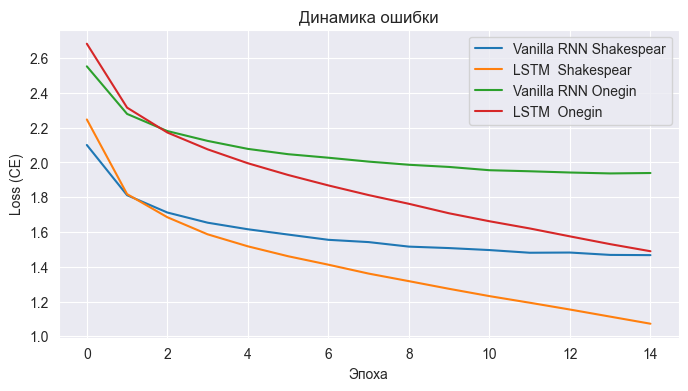

In [118]:
# Your plot code here
#подготовим выборки для обучения
def make_loader(token_to_idx, raw_text):
    seq_len   = 100          # длина входной последовательности
    step      = 3            # шаг скользящего окна
    batch_sz  = 256
    # превращаем текст в последовательность индексов
    data_idx = [token_to_idx[c] for c in raw_text]
    
    # формируем пары (x, y), где y — следующий символ
    X, Y = [], []
    for i in range(0, len(data_idx) - seq_len, step):
        X.append(data_idx[i : i+seq_len])
        Y.append(data_idx[i+seq_len])
    
    # переводим в torch.LongTensor
    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    
    # удобная PyTorch Dataset-обёртка
    from torch.utils.data import TensorDataset, DataLoader
    dataset = TensorDataset(X, Y)
    loader  = DataLoader(dataset, batch_size=batch_sz, shuffle=True, drop_last=True)
    return loader
    
loader_shakespear = make_loader(token_to_idx=token_to_idx_shakespeare, raw_text=text_shakespeare)
loader_onegin  = make_loader(token_to_idx=token_to_idx_onegin, raw_text=text_onegin)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        hidden, cell = model.initial_state(x.size(0))
        optimizer.zero_grad()
        logits, _, _ = model(x, hidden, cell)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

#обучаем шекспира
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
rnn_model_shakespear = CharRNN(rnn_type="RNN", vocab_size = len(tokens_shakespeare), hidden_size=256).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model_shakespear.parameters(), lr=3e-3)
num_epochs = 15
loss_history_rnn_shakespear = []
print('RNN SHAKESPEAR')
for epoch in range(1, num_epochs+1):
    epoch_loss = train_epoch(rnn_model_shakespear, loader_shakespear, criterion, optimizer, device)
    loss_history_rnn_shakespear.append(epoch_loss)
 
lstm_model_shakespear = CharRNN(rnn_type="LSTM", vocab_size = len(tokens_shakespeare), hidden_size=256).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model_shakespear.parameters(), lr=3e-3)
num_epochs = 15
loss_history_lstm_shakespear = []
print('LSTM SHAKESPEAR')
for epoch in range(1, num_epochs+1):
    epoch_loss = train_epoch(lstm_model_shakespear, loader_shakespear, criterion, optimizer, device)
    loss_history_lstm_shakespear.append(epoch_loss)
   
#обучаем онегина
rnn_model_onegin = CharRNN(rnn_type="RNN", vocab_size = len(tokens_onegin), hidden_size=256).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model_onegin.parameters(), lr=3e-3)
num_epochs = 15
loss_history_rnn_onegin = []
print('RNN ONEGIN')
for epoch in range(1, num_epochs+1):
    epoch_loss = train_epoch(rnn_model_onegin, loader_onegin, criterion, optimizer, device)
    loss_history_rnn_onegin.append(epoch_loss)

lstm_model_onegin = CharRNN(rnn_type="LSTM", vocab_size = len(tokens_onegin), hidden_size=256).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model_onegin.parameters(), lr=3e-3)
num_epochs = 15
loss_history_lstm_onegin = []
print('LSTM ONEGIN')
for epoch in range(1, num_epochs+1):
    epoch_loss = train_epoch(lstm_model_onegin, loader_onegin, criterion, optimizer, device)
    loss_history_lstm_onegin.append(epoch_loss)  
 
#у lstm лосс функция будет быстрее обучатся, т.к. lstm более сложная модель чем ванильная rnn   
plt.figure(figsize=(8,4))
plt.plot(loss_history_rnn_shakespear,  label="Vanilla RNN Shakespear")
plt.plot(loss_history_lstm_shakespear, label="LSTM  Shakespear")
plt.plot(loss_history_rnn_onegin,  label="Vanilla RNN Onegin")
plt.plot(loss_history_lstm_onegin, label="LSTM  Onegin")
plt.xlabel("Эпоха")
plt.ylabel("Loss (CE)")
plt.title("Динамика ошибки")
plt.legend(); plt.show()  


In [120]:
@torch.no_grad()
def generate_sample(model,token_to_idx, idx_to_token, vocab_size, seed_text, device, length=400, temperature=1.0):
    model.eval()
    seed_idx = torch.tensor([[token_to_idx[c] for c in seed_text]], dtype=torch.long).to(device)
    hidden, cell = model.initial_state(1)
    out_text = seed_text
    
    for i in range(length):
        logits, hidden, cell = model(seed_idx, hidden, cell)
        logits = logits.squeeze() / temperature
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        next_idx = np.random.choice(range(vocab_size), p=probs)
        next_char = idx_to_token[next_idx]
        out_text += next_char
        seed_idx = torch.tensor([[next_idx]], dtype=torch.long).to(device)
    return out_text

In [121]:
# An example of generated text.
#самые адекватные показатели при температуре 0.5 или 1
seed = "i know what i do,\n"  # небольшая затравка
print("RNN SHAKESPEARE")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(rnn_model_shakespear, token_to_idx_shakespeare, idx_to_token_shakespeare, len(tokens_shakespeare), seed, device=device, length=400, temperature=T))
    print()

print("LSTM SHAKESPEARE")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(lstm_model_shakespear, token_to_idx_shakespeare, idx_to_token_shakespeare, len(tokens_shakespeare), seed, device=device, length=400, temperature=T))
    print() 

seed = "любви все возрасты покорны,\n"  # небольшая затравка
print("RNN ONEGIN")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(rnn_model_onegin, token_to_idx_onegin, idx_to_token_onegin, len(tokens_onegin), seed, device=device, length=400, temperature=T))
    print()

print("LSTM ONEGIN")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(lstm_model_onegin, token_to_idx_onegin, idx_to_token_onegin, len(tokens_onegin), seed, device=device, length=400, temperature=T))
    print()
      

RNN SHAKESPEARE
 Temperature = 0.1

i know what i do,
    and such a doth her possess of the world the world a doth death the such the world a doth death the world the world a doth such a doth death the world the world the such the world a perfore all the such a doth her were and such a doth such the such the such a doth death the such a doth death the world the such the world a doth such the such a doth her world a doth death the world a doth death 

 Temperature = 0.2

i know what i do,
  and such a doth such the such a doth he the world a doth her poserves as the world worth the world the such a doth a doth such such to the such her world thee with the such the world as the some worth the world the world as the world a doth her world so shall the world the world to the world are to the world a doth deather's are the world the world as the such the world as the such such a payes 

 Temperature = 0.5

i know what i do,
  and no more some the some more dear thee, and so doth heart of h

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [69]:
# Your beautiful code here


Модель сохранена в rnn_onegin.pt


KeyError: 'М'

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [47]:
# Text generation with different temperature values here

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [123]:
# Saving and loading code here
model_path = "rnn_onegin.pt"
torch.save({
    "model_state": rnn_model_onegin.state_dict(),
    "token_to_idx": token_to_idx_onegin,
    "idx_to_token": idx_to_token_onegin,
    "params": {
        "rnn_type": "RNN",
        "hidden_size": rnn_model_onegin.hidden_size,
        "num_layers": rnn_model_onegin.num_layers,
        "vocab_size": len(tokens_onegin)
    }
}, model_path)
print("Модель сохранена в", model_path)

#загружаем модель
checkpoint = torch.load(model_path, map_location=device)
params = checkpoint["params"]

loaded_model = CharRNN(**params).to(device)
loaded_model.load_state_dict(checkpoint["model_state"])
loaded_model.eval()

seed = "мама мыла раму,\n" 
print(generate_sample(loaded_model, checkpoint["token_to_idx"], checkpoint["idx_to_token"], checkpoint["params"]["vocab_size"], seed, device=device, length=400, temperature=1))

model_path = "lstm_onegin.pt"
torch.save({
    "model_state": lstm_model_onegin.state_dict(),
    "token_to_idx": token_to_idx_onegin,
    "idx_to_token": idx_to_token_onegin,
    "params": {
        "rnn_type": "LSTM",
        "hidden_size": lstm_model_onegin.hidden_size,
        "num_layers": lstm_model_onegin.num_layers,
        "vocab_size": len(tokens_onegin)
    }
}, model_path)
print("Модель сохранена в", model_path)

#загружаем модель
checkpoint = torch.load(model_path, map_location=device)
params = checkpoint["params"]

loaded_model = CharRNN(**params).to(device)
loaded_model.load_state_dict(checkpoint["model_state"])
loaded_model.eval()

seed = "мама мыла раму,\n" 
print(generate_sample(loaded_model, checkpoint["token_to_idx"], checkpoint["idx_to_token"], checkpoint["params"]["vocab_size"], seed, device=device, length=400, temperature=1))

Модель сохранена в rnn_onegin.pt
мама мыла раму,
чтот жизних, жиртримая на крахи,
укая слуша судиновой деты он уморен пошелый полноваться, а родной гостевий.
но что в,лупастили скорченно вздедно, савая, лет,
что ни полнил с поэтелом но взаре теперь это жанеший от ленск задежна за клачах, чтобому, благовольченным дверь, моровствоге влестных, дитя, дисаны отодимствия ожину
и ять жеттил, меду постеуший евгений,
блаженьям
прощает совел, он ольгин жи
Модель сохранена в lstm_onegin.pt
мама мыла раму,
глядоя рекажатавом,
их вашей играют опета
пленнимный жизненья жизни для свет.



xxiii

и ты, что не дне поэты? нездровил;
но вце себлив за по молчались,
дитя квакацалью стени;
то часто в деперь поголь
вотоварил дом жасто бране
и няжер (что ж? nende ж и том мои следам,
но же родна ее ленском.



xxviii

чтоб легком в тене то на счастливые?
повеезший только из аможит,
и волот и всех абущий,
одит ме


### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)